# Por qué un ECG crudo no sirve para nada

Un electrodo no entrega un electrocardiograma. Entrega una suma de cuatro señales, de
las cuales solo una es cardiaca — y no es la que más potencia tiene.

Este notebook construye esa suma componente por componente, la mira en el dominio de
la frecuencia, y muestra por qué la separación entre señal y ruido no es tan limpia
como parece.

**Requisitos:** `numpy`, `scipy`, `matplotlib`.

In [1]:
import numpy as np
from scipy import signal as sg
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 10, 'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.25, 'axes.spines.top': False,
                     'axes.spines.right': False})

FS = 500     # Hz — frecuencia de muestreo de ECG diagnóstico (la de PTB-XL)
TINTA, ROJO, VERDE, AZUL, NARANJA = '#333', '#c0392b', '#0b6e5f', '#2c5f8a', '#b8730a'

## 1. Las cinco ondas del latido

Antes de hablar de ruido conviene saber qué se está intentando conservar. Cada onda del
ECG corresponde a un evento eléctrico concreto del corazón:

| Onda | Evento | Duración típica | Amplitud |
|---|---|---|---|
| P | Despolarización auricular | 80–100 ms | 0.1–0.2 mV |
| QRS | Despolarización ventricular | 80–100 ms | 1–2.5 mV |
| T | Repolarización ventricular | ~160 ms | 0.2–0.5 mV |

Entre el QRS y la T está el **segmento ST**, un tramo casi plano que corresponde al
momento en que todo el ventrículo está despolarizado. Su nivel es uno de los
indicadores más vigilados en cardiología, y va a reaparecer más adelante.

El generador modela cada onda como una gaussiana. Es el enfoque de McSharry et al.
(2003), simplificado, con una diferencia importante: el intervalo entre latidos varía.
Un ECG exactamente periódico produce un espectro con un peine de armónicos artificial
que no se parece al de una señal real.

In [2]:
def ecg_sintetico(fs=FS, dur=20.0, hr=62.0, amp_r=1.30, hrv=0.045, semilla=7):
    """ECG sintético por suma de gaussianas, con variabilidad natural del RR.

    hrv: desviación estándar del intervalo RR en segundos. Un ritmo perfectamente
         regular (hrv=0) genera un peine espectral artificial.
    """
    rng = np.random.default_rng(semilla)
    n = int(fs * dur); t = np.arange(n) / fs; x = np.zeros(n)

    ondas = [(-0.200,  0.15, 0.025),   # P
             (-0.035, -0.10, 0.008),   # Q
             ( 0.000,  1.10, 0.010),   # R
             ( 0.035, -0.25, 0.010),   # S
             ( 0.280,  0.30, 0.045)]   # T

    rr_medio = 60.0 / hr
    tr = 0.4; picos = []
    while tr < dur - 0.5:
        picos.append(tr)
        for centro, amp, sigma in ondas:
            x += amp * np.exp(-0.5 * ((t - (tr + centro)) / sigma) ** 2)
        tr += max(0.35, rng.normal(rr_medio, hrv))

    return t, x * (amp_r / 1.10), np.array(picos)


t, limpio, picos = ecg_sintetico()
rr = np.diff(picos)
print(f'{len(picos)} latidos en {t[-1]:.0f} s')
print(f'Frecuencia cardiaca media: {60/rr.mean():.1f} lpm')
print(f'SDNN (variabilidad):       {1000*rr.std():.0f} ms')

21 latidos en 20 s
Frecuencia cardiaca media: 62.9 lpm
SDNN (variabilidad):       34 ms


Un SDNN de unas decenas de milisegundos es lo normal en un adulto en reposo. La señal
sintética ya se comporta como una señal fisiológica en ese aspecto.

## 2. Los tres ruidos

Cada uno tiene un origen físico distinto, y ese origen determina en qué frecuencias
aparece.

### Deriva de línea base

El tórax se mueve al respirar, los electrodos se desplazan contra la piel y la
impedancia del contacto cambia. El resultado es una ondulación lenta que hace flotar
todo el trazo. A 17 respiraciones por minuto, la componente respiratoria vive alrededor
de 0.28 Hz.

### Interferencia de red

El cuerpo actúa como una placa de condensador frente al cableado eléctrico del edificio.
Ese acoplo capacitivo inyecta la frecuencia de la red: **60 Hz en México y en toda
Norteamérica, 50 Hz en Europa y buena parte de Asia**. Rara vez llega sola — aparecen
también armónicos en 120 y 180 Hz.

### Artefacto electromiográfico

Si el paciente tensa un músculo, la actividad eléctrica de ese músculo se suma al
registro. Es ruido de banda ancha, aproximadamente entre 20 y 150 Hz, y viene en
ráfagas en vez de ser constante.

In [3]:
def deriva(t, amp=0.35, f_resp=0.28):
    """Deriva de línea base: respiración y movimiento de electrodos."""
    return (amp * np.sin(2*np.pi*f_resp*t)
            + 0.18 * np.sin(2*np.pi*0.09*t + 1.1)
            + 0.08 * np.sin(2*np.pi*0.55*t + 2.3))


def red(t, amp=0.12, f0=60.0):
    """Interferencia de red: fundamental y armónicos. f0=50.0 en Europa."""
    return (amp * np.sin(2*np.pi*f0*t)
            + 0.28*amp * np.sin(2*np.pi*2*f0*t + 0.7)
            + 0.16*amp * np.sin(2*np.pi*3*f0*t + 1.9))


def emg(t, fs, amp=0.05, semilla=11):
    """Artefacto EMG: ruido de banda 20-150 Hz, en ráfagas."""
    rng = np.random.default_rng(semilla)
    sos = sg.butter(4, [20, 150], 'bandpass', fs=fs, output='sos')
    ruido = sg.sosfilt(sos, rng.standard_normal(len(t)))
    envolvente = (1 + 2.2*np.exp(-0.5*((t-8.2)/0.55)**2)
                    + 1.8*np.exp(-0.5*((t-15.1)/0.4)**2))
    return amp * ruido * envolvente


d, r, e = deriva(t), red(t), emg(t, FS)
crudo = limpio + d + r + e

for nombre, s in [('ECG limpio', limpio), ('deriva', d), ('red', r),
                  ('EMG', e), ('CRUDO', crudo)]:
    print(f'{nombre:>11}: RMS = {np.sqrt((s**2).mean()):.3f} mV')

snr = 10*np.log10((limpio**2).mean() / ((d+r+e)**2).mean())
print(f'\nRelación señal/ruido: {snr:+.1f} dB')

 ECG limpio: RMS = 0.211 mV
     deriva: RMS = 0.285 mV
        red: RMS = 0.089 mV
        EMG: RMS = 0.049 mV
      CRUDO: RMS = 0.370 mV

Relación señal/ruido: -3.1 dB


**La SNR es negativa.** En este registro hay más potencia de ruido que de señal
cardiaca, y no es un caso patológico: la deriva sola tiene un RMS mayor que el del ECG.

Vale la pena detenerse en eso. La intuición dice que el ruido es una perturbación
pequeña sobre una señal dominante. En bioseñales suele ser al revés.

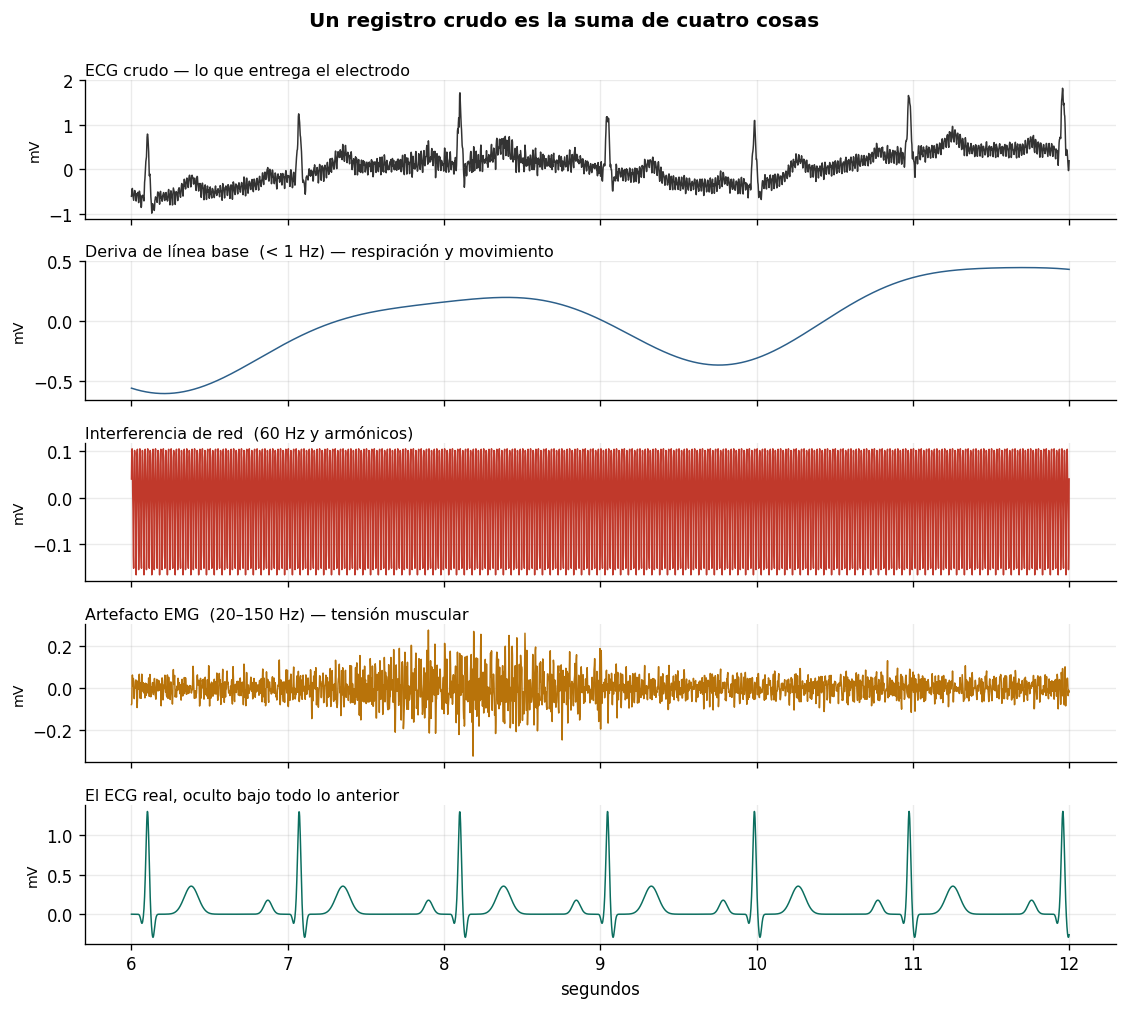

In [4]:
V = (t >= 6) & (t <= 12)   # ventana de 6 s

fig, axes = plt.subplots(5, 1, figsize=(9.5, 8.4), sharex=True)
for ax, (s, titulo, color) in zip(axes, [
        (crudo,  'ECG crudo — lo que entrega el electrodo', TINTA),
        (d,      'Deriva de línea base  (< 1 Hz) — respiración y movimiento', AZUL),
        (r,      'Interferencia de red  (60 Hz y armónicos)', ROJO),
        (e,      'Artefacto EMG  (20–150 Hz) — tensión muscular', NARANJA),
        (limpio, 'El ECG real, oculto bajo todo lo anterior', VERDE)]):
    ax.plot(t[V], s[V], color=color, lw=0.9)
    ax.set_title(titulo, fontsize=9.5, loc='left', pad=3)
    ax.set_ylabel('mV', fontsize=8.5)
axes[0].set_ylim(-1.1, 2.0)
axes[-1].set_xlabel('segundos')
fig.suptitle('Un registro crudo es la suma de cuatro cosas', fontweight='bold', y=0.997)
fig.tight_layout()
plt.show()

En el trazo crudo el QRS todavía se distingue, porque es un pico estrecho y alto. Todo
lo demás —la P, la T, el nivel del ST— está perdido.

## 3. Mirar el espectro

En el dominio del tiempo se ve que hay ruido; en el de la frecuencia se ve **dónde**
está, y eso es lo que permite diseñar un filtro.

Aquí se usa el método de Welch en lugar de una FFT directa. La FFT de un registro
completo es muy ruidosa: Welch parte la señal en segmentos, calcula el espectro de cada
uno y los promedia, lo que da una estimación mucho más estable. Es la elección correcta
para señales largas.

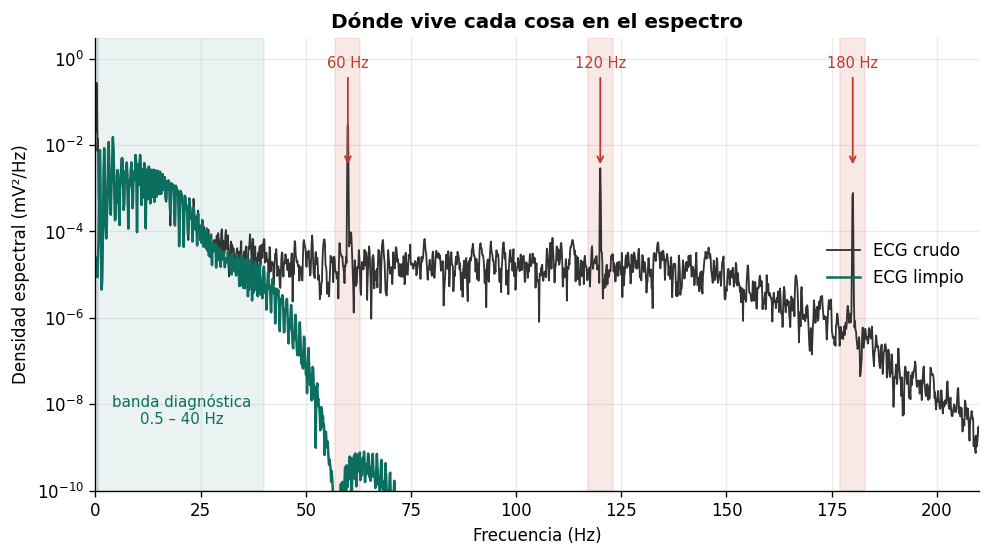

In [5]:
def espectro(x, fs=FS):
    return sg.welch(x, fs=fs, nperseg=4096, noverlap=2048)


f, Pc = espectro(crudo)
f, Pl = espectro(limpio)

fig, ax = plt.subplots(figsize=(9.5, 4.9))
ax.axvspan(0, 0.5, color=AZUL, alpha=0.12)
ax.axvspan(0.5, 40, color=VERDE, alpha=0.08)
for c in (60, 120, 180):
    ax.axvspan(c-3, c+3, color=ROJO, alpha=0.11)

ax.semilogy(f, Pc, color=TINTA, lw=1.1, label='ECG crudo')
ax.semilogy(f, Pl, color=VERDE, lw=1.5, label='ECG limpio')
ax.set_xlim(0, 210); ax.set_ylim(1e-10, 3e0)
ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('Densidad espectral (mV²/Hz)')
ax.set_title('Dónde vive cada cosa en el espectro', fontweight='bold')
ax.legend(loc='center right', frameon=False)
ax.text(20.5, 3e-9, 'banda diagnóstica\n0.5 – 40 Hz',
        fontsize=9, color=VERDE, ha='center', va='bottom')
for c in (60, 120, 180):
    ax.annotate(f'{c} Hz', xy=(c, 3e-3), xytext=(c, 6e-1), fontsize=8.8,
                color=ROJO, ha='center',
                arrowprops=dict(arrowstyle='->', color=ROJO, lw=1.1))
plt.show()

Los tres picos de la red son inconfundibles: líneas verticales estrechas en 60, 120 y
180 Hz. Ese carácter de banda muy angosta es lo que permitirá eliminarlos con un filtro
notch sin tocar casi nada más.

La deriva es el otro extremo: toda su potencia está apretada por debajo de 1 Hz.

El EMG es el caso difícil. No tiene una firma reconocible — es una elevación ancha del
piso de ruido que **se solapa con la banda del ECG**. No hay ninguna frecuencia donde
cortar sin perder señal cardiaca.

## 4. Cuánta energía hay en cada banda

In [6]:
def energia(x, lo, hi):
    f, P = espectro(x)
    m = (f >= lo) & (f < hi)
    return np.trapezoid(P[m], f[m])


print(f"{'banda (Hz)':>13} | {'limpio':>10} | {'crudo':>10} | {'razón':>12}")
print('-' * 54)
for lo, hi, etq in [(0, 0.5, '0 – 0.5'), (0.5, 1, '0.5 – 1'), (1, 40, '1 – 40'),
                    (55, 65, '55 – 65'), (115, 125, '115 – 125'),
                    (20, 150, '20 – 150')]:
    a, b = energia(limpio, lo, hi), energia(crudo, lo, hi)
    razon = b / max(a, 1e-14)
    txt = '> 10⁶' if razon > 1e6 else f'{razon:.0f}x'
    print(f'{etq:>13} | {a:>10.5f} | {b:>10.5f} | {txt:>12}')

   banda (Hz) |     limpio |      crudo |        razón
------------------------------------------------------
      0 – 0.5 |    0.00001 |    0.06085 |        6744x
      0.5 – 1 |    0.00051 |    0.00143 |           3x
       1 – 40 |    0.03673 |    0.03711 |           1x
      55 – 65 |    0.00000 |    0.00749 |        > 10⁶
    115 – 125 |    0.00000 |    0.00067 |        > 10⁶
     20 – 150 |    0.00192 |    0.01226 |           6x


In [7]:
f, P = espectro(limpio)
total = np.trapezoid(P, f)
print('Energía acumulada del ECG limpio:\n')
for limite in (0.5, 1, 5, 15, 40, 100):
    m = f < limite
    print(f'  por debajo de {limite:>5} Hz: {100*np.trapezoid(P[m], f[m])/total:5.1f}%')

Energía acumulada del ECG limpio:

  por debajo de   0.5 Hz:   0.0%
  por debajo de     1 Hz:   1.4%
  por debajo de     5 Hz:  30.5%
  por debajo de    15 Hz:  81.0%
  por debajo de    40 Hz:  99.9%
  por debajo de   100 Hz: 100.0%


Dos lecturas importantes de estas tablas.

**En la banda de 1 a 40 Hz, la razón es 1.** El ruido no aporta ahí prácticamente nada:
esa banda es ECG casi puro. Fuera de ella, la contaminación es de órdenes de magnitud.

**El 99.9% de la energía del ECG está por debajo de 40 Hz**, y apenas un 1.4% por debajo
de 1 Hz. De ahí sale la receta habitual: cortar por abajo de 0.5 Hz y por arriba de
40 Hz debería quitar casi todo el ruido y conservar casi toda la señal.

Esa receta es correcta a medias, y la razón aparece al final del notebook.

## 5. Nyquist: por qué la frecuencia de muestreo ya decidió cosas por ti

El teorema de Nyquist-Shannon dice que para representar sin ambigüedad una componente de
frecuencia $f$ hace falta muestrear a más de $2f$. Lo que suele explicarse peor es lo
que pasa cuando no se cumple: la componente no desaparece, **reaparece en otra
frecuencia**. Se llama aliasing (solapamiento), y la frecuencia aparente es

$$f_{\text{alias}} = \left| f - k \cdot f_s \right|$$

para el entero $k$ que la deja dentro del rango de 0 a $f_s/2$.

Esto importa en la práctica cuando alguien remuestrea una señal para reducir su tamaño.

In [8]:
def frecuencia_alias(f0, fs):
    """Frecuencia aparente de f0 al muestrear a fs sin filtro previo."""
    f = f0 % fs
    return min(f, fs - f)


print(f"{'fs (Hz)':>8} | {'60 Hz →':>9} | {'120 Hz →':>10} | {'180 Hz →':>10}")
print('-' * 45)
for fs in (500, 360, 250, 200, 128, 100):
    print(f'{fs:>8} | {frecuencia_alias(60,fs):>6.1f} Hz | '
          f'{frecuencia_alias(120,fs):>7.1f} Hz | {frecuencia_alias(180,fs):>7.1f} Hz')

 fs (Hz) |   60 Hz → |   120 Hz → |   180 Hz →
---------------------------------------------
     500 |   60.0 Hz |   120.0 Hz |   180.0 Hz
     360 |   60.0 Hz |   120.0 Hz |   180.0 Hz
     250 |   60.0 Hz |   120.0 Hz |    70.0 Hz
     200 |   60.0 Hz |    80.0 Hz |    20.0 Hz
     128 |   60.0 Hz |     8.0 Hz |    52.0 Hz
     100 |   40.0 Hz |    20.0 Hz |    20.0 Hz


Fíjate en la fila de 100 Hz: los 60 Hz aparecen en 40 Hz y los armónicos de 120 y 180
caen ambos en 20 Hz — justo donde el QRS concentra su energía. Una vez ahí,
**son indistinguibles de señal cardiaca real**. Ningún filtro posterior puede separarlos.

Vamos a provocarlo.

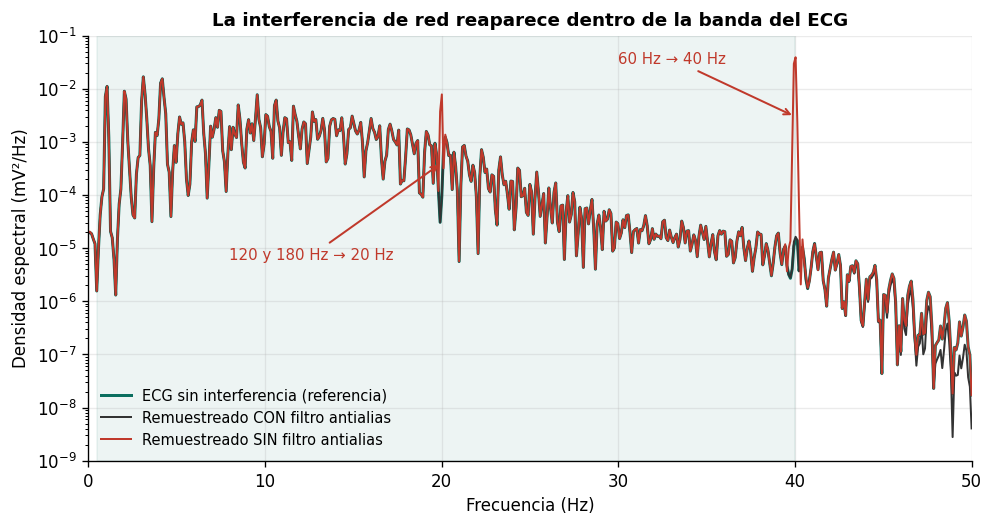

  referencia: potencia en 35–45 Hz = 0.000076
  CON filtro: potencia en 35–45 Hz = 0.000077
  SIN filtro: potencia en 35–45 Hz = 0.007102


In [9]:
Q = 5; FS2 = FS // Q            # 500 -> 100 Hz
x = limpio + r                  # ECG con interferencia de red

mal  = x[::Q]                                          # tomar 1 de cada 5 muestras
bien = sg.decimate(x, Q, ftype='fir', zero_phase=True) # filtra antes de decimar
ref  = limpio[::Q]                                     # referencia sin interferencia

fig, ax = plt.subplots(figsize=(9.5, 4.6))
for s, color, lw, etq in [(ref,  VERDE, 1.8, 'ECG sin interferencia (referencia)'),
                          (bien, TINTA, 1.2, 'Remuestreado CON filtro antialias'),
                          (mal,  ROJO,  1.2, 'Remuestreado SIN filtro antialias')]:
    ff, PP = sg.welch(s, fs=FS2, nperseg=1024, noverlap=512)
    ax.semilogy(ff, PP, color=color, lw=lw, label=etq)

ax.axvspan(0.5, 40, color=VERDE, alpha=0.07)
ax.set_xlim(0, 50); ax.set_ylim(1e-9, 1e-1)
ax.set_xlabel('Frecuencia (Hz)'); ax.set_ylabel('Densidad espectral (mV²/Hz)')
ax.set_title('La interferencia de red reaparece dentro de la banda del ECG',
             fontweight='bold', fontsize=11)
ax.legend(loc='lower left', frameon=False, fontsize=8.8)
ax.annotate('60 Hz → 40 Hz', xy=(40, 3e-3), xytext=(30, 3e-2), fontsize=9, color=ROJO,
            arrowprops=dict(arrowstyle='->', color=ROJO, lw=1.2))
ax.annotate('120 y 180 Hz → 20 Hz', xy=(20, 4e-4), xytext=(8, 6e-6), fontsize=9,
            color=ROJO, arrowprops=dict(arrowstyle='->', color=ROJO, lw=1.2))
plt.show()

for nombre, s in [('referencia', ref), ('CON filtro', bien), ('SIN filtro', mal)]:
    ff, PP = sg.welch(s, fs=FS2, nperseg=1024)
    m = (ff > 35) & (ff < 45)
    print(f'{nombre:>12}: potencia en 35–45 Hz = {np.trapezoid(PP[m], ff[m]):.6f}')

Dos picos que no existían aparecen exactamente donde predijo la fórmula, con unas 90
veces más potencia que la referencia en esa banda. La versión filtrada antes de decimar
es indistinguible de la referencia.

La moraleja operativa: **`x[::n]` no es una forma válida de remuestrear una señal.**
Usa `scipy.signal.decimate`, que aplica el filtro antialias por ti.

## 6. Lo que el espectro no te dice

Con todo lo anterior se puede escribir la receta estándar: paso-alto por debajo de
0.5 Hz para la deriva, notch en 60 Hz para la red, paso-bajo en 40 Hz para el EMG.
El espectro respalda cada paso, y solo se pierde el 0.1% de la energía del ECG.

Ahora una pregunta incómoda.

Vimos que apenas un 1.4% de la energía del ECG está por debajo de 1 Hz. Suena
despreciable. Sin embargo, ese es exactamente el rango donde vive el nivel del segmento
ST, y cortar ahí de forma descuidada puede desplazarlo lo suficiente para simular una
isquemia miocárdica que no existe.

**La energía espectral no es una medida de importancia diagnóstica.** Un tramo plano
tiene poca energía por definición, y aun así su nivel puede decidir si alguien va o no
al cateterismo. El espectro dice dónde está la potencia; no dice qué información
clínica depende de qué frecuencias.

Ese es el tema del siguiente artículo.

---

## Repetir esto con registros reales

```python
import wfdb
registro = wfdb.rdrecord('e0103', pn_dir='edb')   # European ST-T Database
señal, fs = registro.p_signal[:, 0], registro.fs
```

Sobre la elección de base de datos:

- **MIT-BIH Arrhythmia** (`pn_dir='mitdb'`) trae un paso-banda de 0.1–100 Hz ya aplicado
  en la adquisición. Es la base más usada en tutoriales, pero para estudiar ruido de baja
  frecuencia o segmento ST parte del fenómeno ya fue eliminado.
- **European ST-T Database** (`pn_dir='edb'`) y **PTB-XL** conservan mejor las bajas
  frecuencias.
- **MIT-BIH Noise Stress Test** (`pn_dir='nstdb'`) contiene registros de ruido real
  —deriva, EMG y artefacto de electrodo grabados de sujetos— que puedes sumar a un ECG
  limpio en la proporción que quieras. Es la forma correcta de hacer este experimento
  con ruido no sintético.

## Referencias

- McSharry P. et al. *A dynamical model for generating synthetic electrocardiogram
  signals.* IEEE Trans. Biomed. Eng., 2003.
- Kligfield P. et al. *Recommendations for the Standardization and Interpretation of the
  Electrocardiogram, Part I.* Circulation, 2007.
- Moody G. et al. *A noise stress test for arrhythmia detectors.* Computers in
  Cardiology, 1984.